In [1]:
import torch
import numpy as np
import tonic
import matplotlib.pyplot as plt
import tonic.transforms as transforms
from asynctorch.simulator.async_simulator import AsyncSimulator
from asynctorch.nn.architecture.mixed_architecture import MixedArchitecture, AsyncNetwork, AsyncLayer
from asynctorch.nn.neuron.lif_state import LIFState
from asynctorch.simulator.extensions.spike_dropout_extension import SpikeDropoutExtension
from asynctorch.simulator.spike_scheduler import RandomSpikeScheduler, MomentumSpikeScheduler
from asynctorch.simulator.spike_selector import SpikeSelector
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
import snntorch.functional as SF
from asynctorch.utils.surrogate import Atan, FastSigmoid
from math import prod
from snntorch import spikegen
from torchvision import datasets, transforms
import statistics
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/home/roel/asynctorch/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
transform = transforms.Compose([
            transforms.Resize((32,32)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

train_dataset = datasets.CIFAR10("./data", train=True, download=True, transform=transform)

Files already downloaded and verified


In [8]:
n_outputs = 10
shape_per_layer = [
    (1, 32, 32),
    (32, 16, 16),
    (64, 8, 8),
    (128, 4, 4),
    (64*2*2, ),
    (256, ),
    (n_outputs, )
]

class VGGLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False, add_pool=True):
        super(VGGLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=bias)
        self.add_pool = add_pool
        if add_pool:
            self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(x)
        if self.add_pool:
            x = self.pool(x)
        return x

module_per_layer = [VGGLayer(1, 32),
                    VGGLayer(32, 64), 
                    VGGLayer(64, 128),
                    VGGLayer(128, 64),
                    nn.Linear(prod(shape_per_layer[-3]), prod(shape_per_layer[-2]), bias=False),
                    nn.Linear(prod(shape_per_layer[-2]), prod(shape_per_layer[-1]), bias=False)]
neurons_per_layer = [prod(shape) for shape in shape_per_layer[1:]]
n_neurons = sum(neurons_per_layer)

In [9]:
for module in module_per_layer:
    if hasattr(module, 'weight'):
        nn.init.xavier_uniform_(module.weight)
        
# Network architecture
async_network = AsyncNetwork.build_sequential(module_per_layer, shape_per_layer).to(device)
print(async_network)
print('Number of neurons:', n_neurons)
print('Number of parameters:', sum(p.numel() for p in async_network.parameters() if p.requires_grad))
network_module = MixedArchitecture(async_network, device)
input_dropout = SpikeDropoutExtension(p=0.1, apply_to_input=True, apply_to_network=False)

# Neuron model
spike_grad = Atan()
state_module = LIFState(
    neurons_per_layer,
    tau_m=20,
    membrane_threshold=0.3,
    spike_grad=spike_grad,
    device=device,
    refrac_dropout=0.7,
    backprop_threshold=None
)

# Simulator
spike_scheduler = RandomSpikeScheduler(state_module)
spike_selector_module = SpikeSelector(
    network_module,
    spike_scheduler,
    forward_group_size=128,
    device=device,
    prioritize_input=True,
    log_queue_length=True
)

AsyncNetwork(
  (input_layer): AsyncLayer(
    (module): VGGLayer(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
  )
  (layers): ModuleList(
    (0): AsyncLayer(
      (module): VGGLayer(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
      )
    )
    (1): AsyncLayer(
      (module): VGGLayer(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
      )
    )
    (2): AsyncLayer(
      (module): VGGLayer(
        (conv): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
      )
    )
    (3): AsyncLayer(
      (module): Linear(in_features=256, out_features=256, bias=False)
    

## Start training
For training, we use the standard PyTorch training loop with some snnTorch specific functions. Instead of calling a forward pass on the network, we call the forward function of the simulator. This function takes the input data and the time step, and returns the output spikes of the network. The output spikes can then be used to calculate the loss and update the weights of the network.

In [10]:
async_simulator = AsyncSimulator(state_module, spike_selector_module, forward_step_extensions=[input_dropout])
#async_simulator.load_state_dict(torch.load('./cifar10_asynctorch.pt'))
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
async_simulator.train()
n_epochs = 1
timesteps = 10
optimizer = torch.optim.Adam(async_simulator.parameters(), lr=1e-3)#, weight_decay=1e-5)
loss_fn = SF.ce_rate_loss()
accuracy_function = SF.accuracy_rate
losses = []
accuracies = []
for epoch in range(n_epochs):
    batch_iter = iter(train_dataloader)
    for data, targets in tqdm(batch_iter):
        data = data.to(device)
        data = spikegen.rate(data, timesteps)
        targets = targets.to(device)
        async_simulator.reset_state()

        # Forward pass
        ys = []
        for t in range(data.shape[0]):
            ts_data = data[t].view(data[t].shape[0], -1)
            spk_out = async_simulator(ts_data, dt=1)[:, n_neurons-n_outputs:]
            ys.append(spk_out) 
        y = torch.stack(ys)
        loss = loss_fn(y, targets)
        losses.append(loss.item())
        accuracy = accuracy_function(y, targets)
        accuracies.append(accuracy)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

  0%|          | 0/782 [00:00<?, ?it/s]

 16%|█▌        | 123/782 [02:30<13:25,  1.22s/it]


KeyboardInterrupt: 

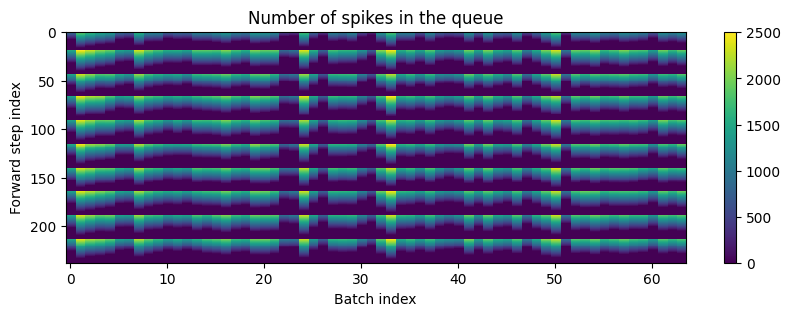

In [11]:
queue_log = np.array(async_simulator.spike_selector.queue_log)
# plot heatmap
plt.figure(figsize=(10, 3))
plt.imshow(queue_log, aspect='auto', interpolation='none')
plt.colorbar()
plt.ylabel('Forward step index')
plt.xlabel('Batch index')
plt.title('Number of spikes in the queue')
plt.show()

### Check training progress

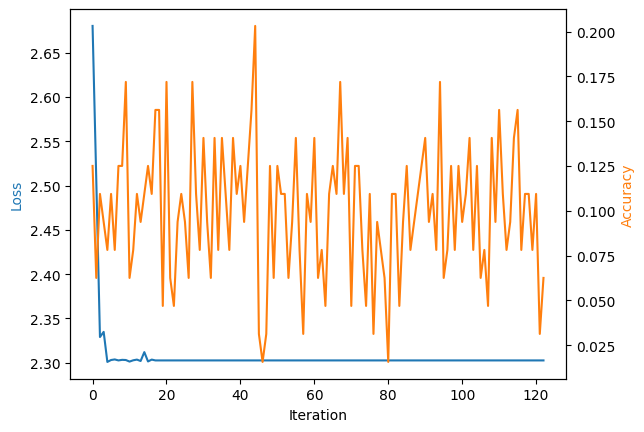

Accuracy:  0.09875


In [12]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(losses, color='C0')
ax2.plot(accuracies, color='C1')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss', color='C0')
ax2.set_ylabel('Accuracy', color='C1')

plt.show()
print("Accuracy: ", statistics.mean(accuracies[-100:]))

In [ ]:
torch.save(async_simulator.state_dict(), "./cifar10_asynctorch.pt")